<a href="https://colab.research.google.com/github/andersonmoraix/anotacoeseconometria/blob/main/A3_econometria_modelo4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#instalando as bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson

In [ ]:
caminho = '/content/iron_ore_2012_2022.xlsx'

# Exportações brasileiras de minerais
export = pd.read_excel(caminho, sheet_name='Minerio Preco')
export.columns = ['Data_fmt', 'Exportacoes']

# PIB China
pib = pd.read_excel(caminho, sheet_name='PIB China')
pib.columns = ['Data_fmt', 'PIB_China']

# BDI
bdi = pd.read_excel(caminho, sheet_name='Balti Dry Index - Frete', skiprows=40, header=0)
bdi.columns = ['Data', 'BDI']
bdi = bdi.dropna()
bdi['Data'] = pd.to_datetime(bdi['Data'], format='%d.%m.%Y')
bdi['Data_fmt'] = bdi['Data'].dt.strftime('%Y.%m')
bdi['BDI'] = pd.to_numeric(bdi['BDI'], errors='coerce')

# Forçar chave para string
export['Data_fmt'] = export['Data_fmt'].astype(str)
pib['Data_fmt']    = pib['Data_fmt'].astype(str)
bdi['Data_fmt']    = bdi['Data_fmt'].astype(str)

print(f"Exportações: {len(export)} linhas | {export['Data_fmt'].iloc[0]} → {export['Data_fmt'].iloc[-1]}")
print(f"PIB China:   {len(pib)} linhas | {pib['Data_fmt'].iloc[0]} → {pib['Data_fmt'].iloc[-1]}")
print(f"BDI:         {len(bdi)} linhas | {bdi['Data_fmt'].iloc[0]} → {bdi['Data_fmt'].iloc[-1]}")

Exportações: 132 linhas | 2012.01 → 2022.12
PIB China:   132 linhas | 2012.01 → 2022.12
BDI:         132 linhas | 2012.01 → 2022.12


In [ ]:
#Merge do arquivos

df = export \
    .merge(bdi[['Data_fmt', 'BDI']], on='Data_fmt') \
    .merge(pib, on='Data_fmt')

df['Data'] = pd.to_datetime(df['Data_fmt'].str.replace('.', '-', regex=False) + '-01')
df = df.sort_values('Data').reset_index(drop=True)

print(f"Total de observações: {len(df)}")
print(df[['Data_fmt', 'Exportacoes', 'BDI', 'PIB_China']].head())

Total de observações: 121
  Data_fmt  Exportacoes   BDI  PIB_China
0  2012.01       171.18   680   7.856174
1  2012.02       167.89   750   7.849720
2  2012.03       169.80   923   7.843266
3  2012.04       172.23  1155   7.836812
4  2012.05       176.93  1004   7.830358


In [ ]:
#estatisticas e correlações

print("=== Estatísticas descritivas ===")
print(df[['Exportacoes', 'BDI', 'PIB_China']].describe().round(2))

print("\n=== Correlações ===")
print(df[['Exportacoes', 'BDI', 'PIB_China']].corr().round(3))

=== Estatísticas descritivas ===
       Exportacoes      BDI  PIB_China
count       121.00   121.00     121.00
mean        133.00  1258.88       6.32
std          50.24   724.84       1.45
min          48.72   315.00       2.34
25%          95.40   782.00       5.46
50%         125.47  1090.00       6.82
75%         169.80  1463.00       7.34
max         290.20  5167.00       8.57

=== Correlações ===
             Exportacoes    BDI  PIB_China
Exportacoes        1.000  0.656     -0.011
BDI                0.656  1.000     -0.275
PIB_China         -0.011 -0.275      1.000


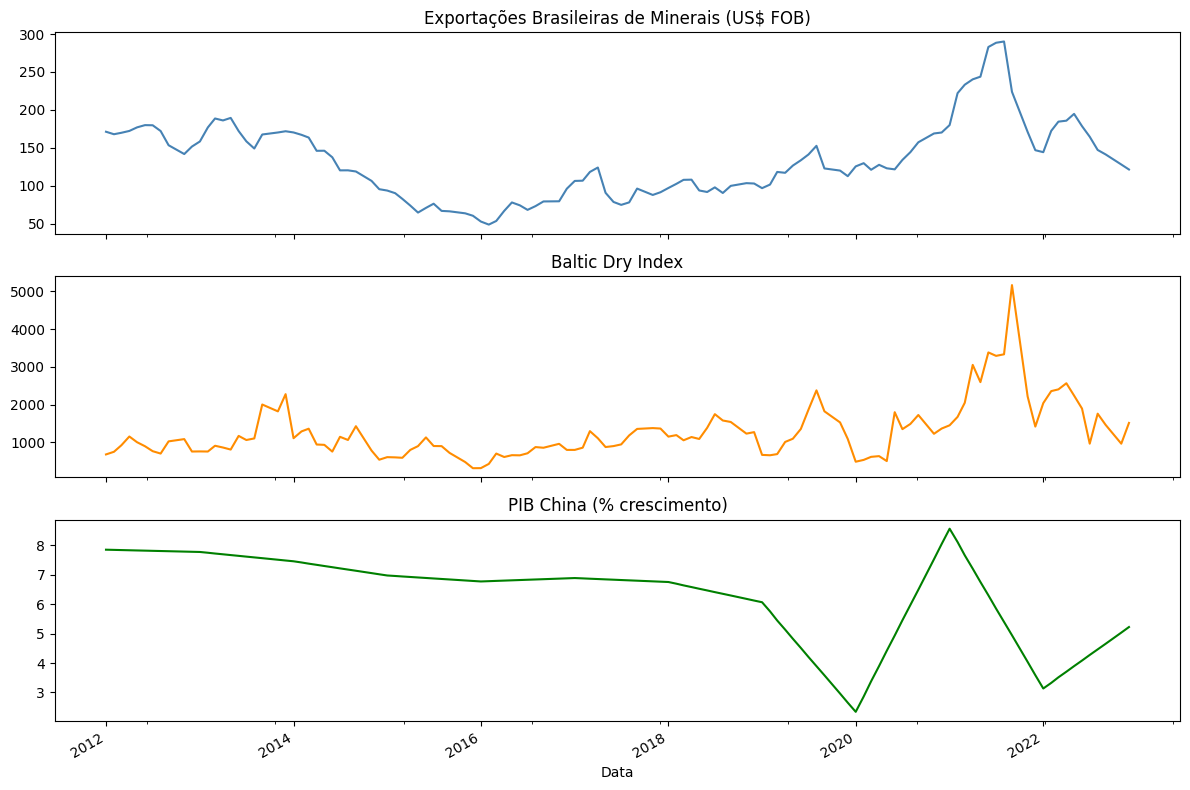

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

df.plot(x='Data', y='Exportacoes', ax=axes[0], title='Exportações Brasileiras de Minerais (US$ FOB)', legend=False, color='steelblue')
df.plot(x='Data', y='BDI',         ax=axes[1], title='Baltic Dry Index',                               legend=False, color='darkorange')
df.plot(x='Data', y='PIB_China',   ax=axes[2], title='PIB China (% crescimento)',                      legend=False, color='green')

plt.tight_layout()
plt.show()

In [ ]:
#Regressão

# Y = Exportações BR | X1 = BDI | X2 = PIB China
modelo = smf.ols('Exportacoes ~ BDI + PIB_China', data=df)
resultado = modelo.fit()
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:            Exportacoes   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     50.56
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.38e-16
Time:                        23:51:59   Log-Likelihood:                -607.67
No. Observations:                 121   AIC:                             1221.
Df Residuals:                     118   BIC:                             1230.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     31.1801     18.377      1.697      0.0

Durbin-Watson: 0.4395
(~2 = sem autocorrelação | <1 = positiva | >3 = negativa)


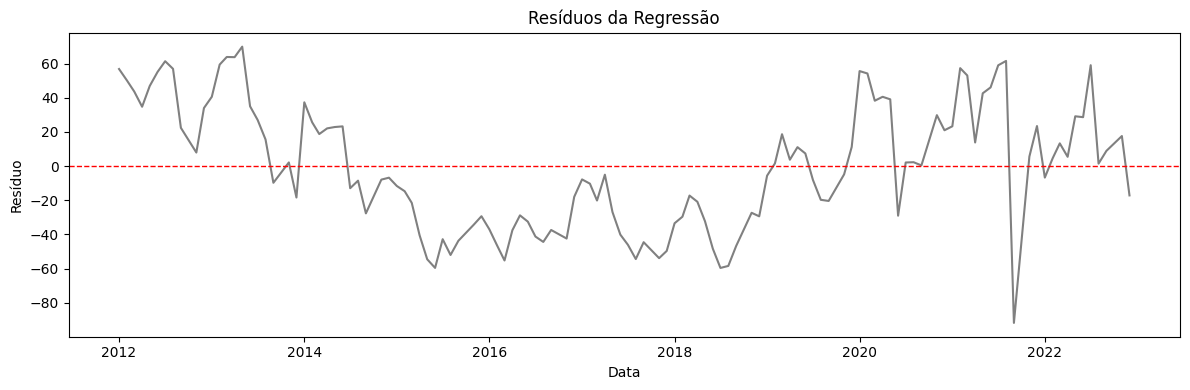


R²          = 0.4615
R² ajustado = 0.4524

Coeficientes:
Intercept    31.1801
BDI           0.0490
PIB_China     6.3537
dtype: float64

P-valores:
Intercept    0.0924
BDI          0.0000
PIB_China    0.0102
dtype: float64


In [ ]:
dw = durbin_watson(resultado.resid)
print(f"Durbin-Watson: {dw:.4f}")
print("(~2 = sem autocorrelação | <1 = positiva | >3 = negativa)")

plt.figure(figsize=(12, 4))
plt.plot(df['Data'], resultado.resid, color='gray')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Resíduos da Regressão')
plt.xlabel('Data')
plt.ylabel('Resíduo')
plt.tight_layout()
plt.show()

print(f"\nR²          = {resultado.rsquared:.4f}")
print(f"R² ajustado = {resultado.rsquared_adj:.4f}")
print(f"\nCoeficientes:\n{resultado.params.round(4)}")
print(f"\nP-valores:\n{resultado.pvalues.round(4)}")

In [ ]:
#Testando com variação anual

# Variação anual = mês atual menos mesmo mês do ano anterior
df['dExport'] = df['Exportacoes'].diff(12)
df['dBDI']    = df['BDI'].diff(12)
df['dPIB']    = df['PIB_China'].diff(12)

# Remove os primeiros 12 meses com NaN
df_anual = df.dropna(subset=['dExport', 'dBDI', 'dPIB']).copy()

print(f"Total de observações: {len(df_anual)}")
print(df_anual[['Data_fmt', 'dExport', 'dBDI', 'dPIB']].head())

Total de observações: 109
   Data_fmt  dExport   dBDI      dPIB
12  2013.02     5.69   77.0 -0.103852
13  2013.03    20.76  160.0 -0.123800
14  2013.04    16.28  -60.0 -0.143748
15  2013.05    17.19 -346.0 -0.163696
16  2013.06    -4.86  167.0 -0.183643


In [ ]:
modelo_anual = smf.ols('dExport ~ dBDI + dPIB', data=df_anual)
resultado_anual = modelo_anual.fit()
print(resultado_anual.summary())

                            OLS Regression Results                            
Dep. Variable:                dExport   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     74.53
Date:                Sun, 31 May 2026   Prob (F-statistic):           6.17e-21
Time:                        23:56:17   Log-Likelihood:                -544.77
No. Observations:                 109   AIC:                             1096.
Df Residuals:                     106   BIC:                             1104.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.9959      3.600     -0.554      0.5

Durbin-Watson original:  0.439  ← autocorrelação forte
Durbin-Watson corrigido: 0.7203  ← deve estar próximo de 2


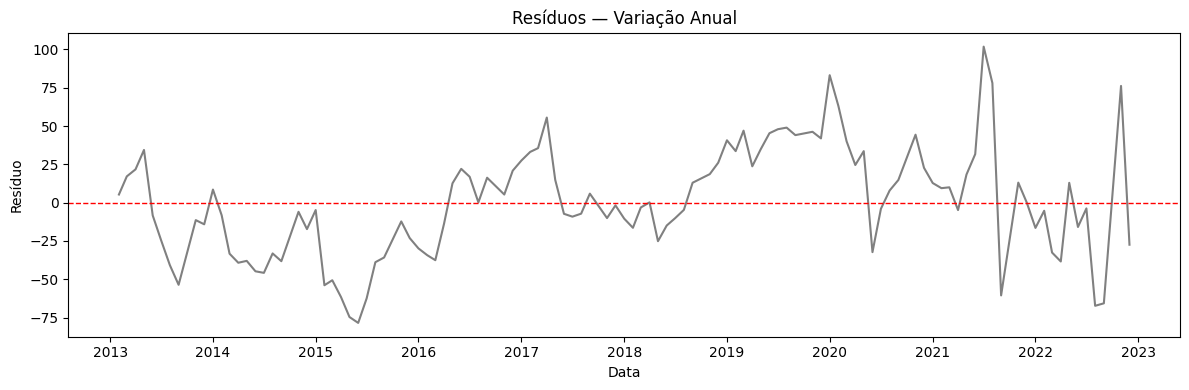


R²          = 0.5844
R² ajustado = 0.5766

Coeficientes:
Intercept   -1.9959
dBDI         0.0406
dPIB         7.0799
dtype: float64

P-valores:
Intercept    0.5805
dBDI         0.0000
dPIB         0.0003
dtype: float64


In [ ]:
dw_anual = durbin_watson(resultado_anual.resid)
print(f"Durbin-Watson original:  0.439  ← autocorrelação forte")
print(f"Durbin-Watson corrigido: {dw_anual:.4f}  ← deve estar próximo de 2")

plt.figure(figsize=(12, 4))
plt.plot(df_anual['Data'].values, resultado_anual.resid, color='gray')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Resíduos — Variação Anual')
plt.xlabel('Data')
plt.ylabel('Resíduo')
plt.tight_layout()
plt.show()

print(f"\nR²          = {resultado_anual.rsquared:.4f}")
print(f"R² ajustado = {resultado_anual.rsquared_adj:.4f}")
print(f"\nCoeficientes:\n{resultado_anual.params.round(4)}")
print(f"\nP-valores:\n{resultado_anual.pvalues.round(4)}")

In [ ]:
#estimando o p valor sobre a variação anual
#durbin watson em dois estagios

# Criar variáveis defasadas (t-1) sobre as variações anuais
df_anual['dExport_lag'] = df_anual['dExport'].shift(1)
df_anual['dBDI_lag']    = df_anual['dBDI'].shift(1)
df_anual['dPIB_lag']    = df_anual['dPIB'].shift(1)

# Remove linha com NaN
df_lag2 = df_anual.dropna().copy()

# Regredir com defasadas para estimar o rô
modelo_rho2 = smf.ols(
    'dExport ~ dExport_lag + dBDI + dBDI_lag + dPIB + dPIB_lag',
    data=df_lag2
)
resultado_rho2 = modelo_rho2.fit()

# O rô é o coeficiente de dExport_lag
rho2 = resultado_rho2.params['dExport_lag']
print(f"ρ (rô) estimado = {rho2:.4f}")

ρ (rô) estimado = 0.8960


In [ ]:
#transformando as variavies

df_lag2['W2']      = df_lag2['dExport'] - rho2 * df_lag2['dExport_lag']
df_lag2['Z2_BDI']  = df_lag2['dBDI']   - rho2 * df_lag2['dBDI_lag']
df_lag2['Z2_PIB']  = df_lag2['dPIB']   - rho2 * df_lag2['dPIB_lag']

print("Variáveis transformadas:")
print(df_lag2[['Data_fmt', 'W2', 'Z2_BDI', 'Z2_PIB']].head())

Variáveis transformadas:
   Data_fmt         W2      Z2_BDI    Z2_PIB
13  2013.03  15.661798   91.008513 -0.030749
14  2013.04  -2.320822 -203.358934 -0.032824
15  2013.05   2.603228 -292.240400 -0.034899
16  2013.06 -20.262125  477.013695 -0.036973
17  2013.07 -17.015472   15.369113 -0.039048


In [ ]:
#Regressão corrigida

modelo_corrigido2 = smf.ols('W2 ~ Z2_BDI + Z2_PIB', data=df_lag2)
resultado_corrigido2 = modelo_corrigido2.fit()
print(resultado_corrigido2.summary())

                            OLS Regression Results                            
Dep. Variable:                     W2   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     7.412
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           0.000975
Time:                        00:00:25   Log-Likelihood:                -468.65
No. Observations:                 108   AIC:                             943.3
Df Residuals:                     105   BIC:                             951.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3346      1.814     -0.184      0.8

Durbin-Watson original:       0.439
Durbin-Watson variação anual: 0.720
Durbin-Watson corrigido:      1.2625  ← ideal próximo de 2


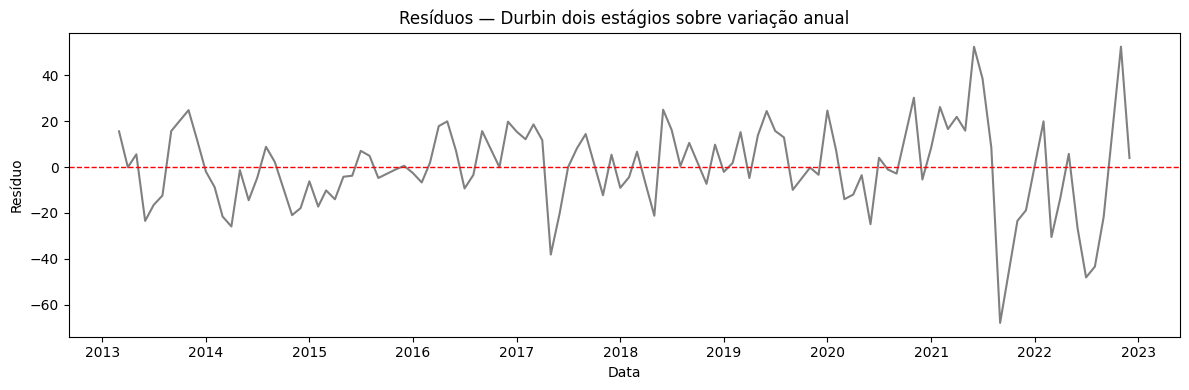


R²          = 0.1237
R² ajustado = 0.1070

Coeficientes:
Intercept   -0.3346
Z2_BDI       0.0080
Z2_PIB       7.5364
dtype: float64

P-valores:
Intercept    0.8540
Z2_BDI       0.0032
Z2_PIB       0.0360
dtype: float64


In [ ]:
dw_final = durbin_watson(resultado_corrigido2.resid)

print(f"Durbin-Watson original:       0.439")
print(f"Durbin-Watson variação anual: 0.720")
print(f"Durbin-Watson corrigido:      {dw_final:.4f}  ← ideal próximo de 2")

plt.figure(figsize=(12, 4))
plt.plot(df_lag2['Data'].values, resultado_corrigido2.resid, color='gray')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Resíduos — Durbin dois estágios sobre variação anual')
plt.xlabel('Data')
plt.ylabel('Resíduo')
plt.tight_layout()
plt.show()

print(f"\nR²          = {resultado_corrigido2.rsquared:.4f}")
print(f"R² ajustado = {resultado_corrigido2.rsquared_adj:.4f}")
print(f"\nCoeficientes:\n{resultado_corrigido2.params.round(4)}")
print(f"\nP-valores:\n{resultado_corrigido2.pvalues.round(4)}")